# A Limit of a Function

This notebook follows the same style as the previous notebooks and introduces the idea of the **limit of a function**.

It covers:

- the intuitive meaning of a function limit
- continuous vs non-continuous cases
- a worked example with
  $$
  \frac{x^2+x-2}{x-1}
  $$
- the formal $\varepsilon$-$\delta$ definition
- Heine's sequential viewpoint
- limits as $x \to +\infty$ and $x \to -\infty$
- Python plots and numerical experiments


## 1. What is a limit of a function?

In general, a limit tells us what value a function is **approaching** as the input approaches a particular point.

We write this as

$$
\lim_{x\to a} f(x) = A
$$

This means:

> when $x$ gets close to $a$, the function values $f(x)$ get close to $A$.

This idea is fundamental in calculus, physics, engineering, and many other fields.


## 2. If the function is continuous

If a function is continuous at $a$, then the limit is easy:

$$
\lim_{x\to a} f(x)=f(a)
$$

So in the continuous case, we can simply substitute $x=a$.

But not every function is defined at the point we approach, and even when it is not defined there, the limit may still exist.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 + 2*x + 1

a = 3
print("f(3) =", f(a))
print("Since f is a polynomial, it is continuous.")
print("So lim x->3 f(x) =", f(a))


f(3) = 16
Since f is a polynomial, it is continuous.
So lim x->3 f(x) = 16


## 3. A non-continuous example

Consider the function

$$
g(x)=\frac{x^2+x-2}{x-1}
$$

and suppose we want to compute

$$
\lim_{x\to 1}\frac{x^2+x-2}{x-1}.
$$

If we substitute $x=1$, we get

$$
\frac{1^2+1-2}{1-1} = \frac{0}{0},
$$

which is undefined.

So direct substitution does **not** work.


In [2]:
def g(x):
    return (x**2 + x - 2) / (x - 1)

try:
    print(g(1))
except Exception as e:
    print("g(1) is undefined:", e)


g(1) is undefined: division by zero


## 4. Numerical evidence for the limit

Let us evaluate $g(x)$ for numbers close to 1:

- $x=0.9$
- $x=0.99$
- $x=0.999$

and also from the other side:

- $x=1.1$
- $x=1.01$
- $x=1.001$


In [3]:
xs_left = [0.9, 0.99, 0.999]
xs_right = [1.1, 1.01, 1.001]

print("Approaching from the left:")
for x in xs_left:
    print(f"x = {x}, g(x) = {g(x)}")

print()
print("Approaching from the right:")
for x in xs_right:
    print(f"x = {x}, g(x) = {g(x)}")


Approaching from the left:
x = 0.9, g(x) = 2.900000000000001
x = 0.99, g(x) = 2.990000000000001
x = 0.999, g(x) = 2.9989999999999712

Approaching from the right:
x = 1.1, g(x) = 3.1000000000000023
x = 1.01, g(x) = 3.009999999999999
x = 1.001, g(x) = 3.0009999999996957


From these values, it looks like

$$
g(x) \to 3 \quad \text{as } x \to 1.
$$


## 5. Simplifying the expression

We factor the numerator:

$$
x^2+x-2 = (x+2)(x-1)
$$

So for $x \ne 1$,

$$
\frac{x^2+x-2}{x-1} = \frac{(x+2)(x-1)}{x-1} = x+2.
$$

Therefore,

$$
\lim_{x\to 1}\frac{x^2+x-2}{x-1}
=
\lim_{x\to 1}(x+2)=3.
$$

So even though the function is not defined at $x=1$, the limit exists and equals 3.


In [4]:
import sympy as sp

x = sp.symbols('x')
expr = (x**2 + x - 2) / (x - 1)

print("Factored numerator:", sp.factor(x**2 + x - 2))
print("Simplified expression for x != 1:", sp.simplify(expr))
print("Limit as x -> 1:", sp.limit(expr, x, 1))


Factored numerator: (x - 1)*(x + 2)
Simplified expression for x != 1: x + 2
Limit as x -> 1: 3


## 6. Graph of the example

The graph behaves like the line

$$
y=x+2
$$

except that the point at $x=1$ is missing.

So the graph has a **hole** at $(1,3)$.


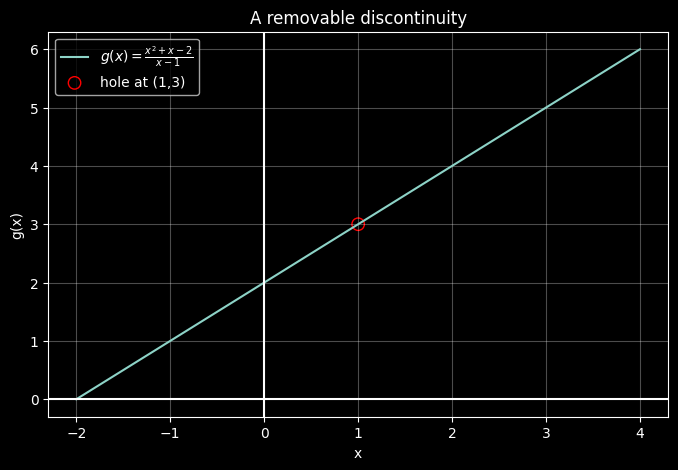

In [6]:
xs = np.linspace(-2, 4, 600)
ys = (xs**2 + xs - 2) / (xs - 1)

mask = np.abs(xs - 1) > 1e-3

plt.figure(figsize=(8,5))
plt.plot(xs[mask], ys[mask], label=r"$g(x)=\frac{x^2+x-2}{x-1}$")
plt.scatter([1], [3], s=80, facecolors='none', edgecolors='red', label="hole at (1,3)")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("g(x)")
plt.title("A removable discontinuity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7. Heine's sequential viewpoint

A useful way to understand limits is through sequences.

The statement

$$
\lim_{x\to a} f(x)=A
$$

means:

> for every sequence $(x_n)$ such that $x_n \to a$ and $x_n \ne a$, we have
> $$
> f(x_n) \to A.
> $$

This is often called **Heine's definition** of the limit.


In [7]:
def seq_test(seq):
    vals = [g(t) for t in seq]
    return list(zip(seq, vals))

seq1 = [0.9, 0.99, 0.999, 0.9999]
seq2 = [1.1, 1.01, 1.001, 1.0001]

print("Sequence approaching 1 from the left:")
for item in seq_test(seq1):
    print(item)

print()
print("Sequence approaching 1 from the right:")
for item in seq_test(seq2):
    print(item)


Sequence approaching 1 from the left:
(0.9, 2.900000000000001)
(0.99, 2.990000000000001)
(0.999, 2.9989999999999712)
(0.9999, 2.9998999999983873)

Sequence approaching 1 from the right:
(1.1, 3.1000000000000023)
(1.01, 3.009999999999999)
(1.001, 3.0009999999996957)
(1.0001, 3.0001000000016127)


## 8. Formal definition: the $\varepsilon$-$\delta$ definition

We say

$$
\lim_{x\to a} f(x)=A
$$

if the following condition holds:

> for every $\varepsilon > 0$, there exists $\delta > 0$ such that
> $$
> 0 < |x-a| < \delta \implies |f(x)-A| < \varepsilon.
> $$

This is the formal definition of a function limit.


## 9. Interpreting the definition

The definition says:

- choose how close you want the function value to be to $A$
- this closeness is measured by $\varepsilon$
- then we can find a small interval around $a$
- this interval is controlled by $\delta$
- whenever $x$ lies in that interval, but is not equal to $a$, the function value lies within $\varepsilon$ of $A$

So:

- input closeness: $|x-a| < \delta$
- output closeness: $|f(x)-A| < \varepsilon$


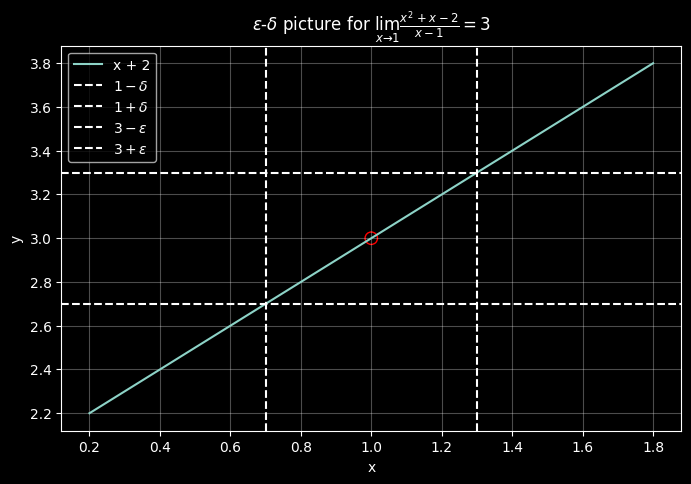

In [11]:
# A simple epsilon-delta picture for the example limit = 3 at x=1
eps = 0.3
delta = eps  # for this example, delta = epsilon works after simplification

xs = np.linspace(0.2, 1.8, 400)
ys = xs + 2  # same as g(x) away from x=1

plt.figure(figsize=(8,5))
plt.plot(xs, ys, label="x + 2")
plt.axvline(1 - delta, linestyle='--', label=r"$1-\delta$")
plt.axvline(1 + delta, linestyle='--', label=r"$1+\delta$")
plt.axhline(3 - eps, linestyle='--', label=r"$3-\varepsilon$")
plt.axhline(3 + eps, linestyle='--', label=r"$3+\varepsilon$")
plt.scatter([1], [3], s=80, facecolors='none', edgecolors='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$\varepsilon$-$\delta$ picture for $\lim_{x\to 1} \frac{x^2+x-2}{x-1}=3$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 10. Proving the example limit formally

We want to prove:

$$
\lim_{x\to 1}\frac{x^2+x-2}{x-1}=3.
$$

For $x \ne 1$,

$$
\frac{x^2+x-2}{x-1} = x+2.
$$

So:

$$
\left|\frac{x^2+x-2}{x-1} - 3\right|
=
|x+2-3|
=
|x-1|.
$$

Therefore, if we want

$$
\left|\frac{x^2+x-2}{x-1} - 3\right| < \varepsilon,
$$

it is enough to require

$$
|x-1| < \varepsilon.
$$

So we can choose

$$
\delta = \varepsilon.
$$

That proves the limit.


In [12]:
epsilons = [0.5, 0.1, 0.01]

for eps in epsilons:
    delta = eps
    print(f"For epsilon = {eps}, choose delta = {delta}")


For epsilon = 0.5, choose delta = 0.5
For epsilon = 0.1, choose delta = 0.1
For epsilon = 0.01, choose delta = 0.01


## 11. One-sided limits

Sometimes we only approach from one side.

### Left-hand limit
$$
\lim_{x\to a^-} f(x)
$$

### Right-hand limit
$$
\lim_{x\to a^+} f(x)
$$

A two-sided limit exists if the left-hand and right-hand limits both exist and are equal.


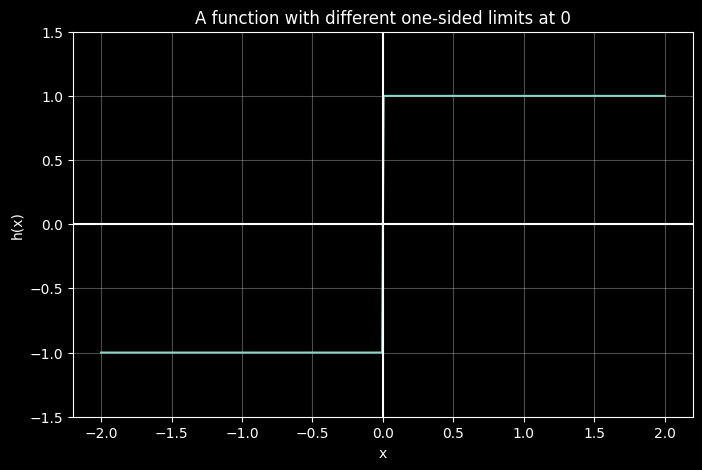

Left-hand limit at 0 is -1
Right-hand limit at 0 is 1
So the two-sided limit at 0 does not exist


In [13]:
# Example of one-sided behavior
def h(x):
    return np.where(x < 0, -1, 1)

xs = np.linspace(-2, 2, 400)
ys = h(xs)

plt.figure(figsize=(8,5))
plt.plot(xs, ys)
plt.axhline(0)
plt.axvline(0)
plt.ylim(-1.5, 1.5)
plt.title("A function with different one-sided limits at 0")
plt.xlabel("x")
plt.ylabel("h(x)")
plt.grid(True, alpha=0.3)
plt.show()

print("Left-hand limit at 0 is -1")
print("Right-hand limit at 0 is 1")
print("So the two-sided limit at 0 does not exist")


## 12. Limits at infinity

We may also ask how a function behaves when $x$ becomes very large:

$$
\lim_{x\to +\infty} f(x)
$$

or very negative:

$$
\lim_{x\to -\infty} f(x).
$$

These describe the **end behavior** of the function.


## 13. Formal definitions at infinity

### Limit as $x \to \infty$
We say

$$
\lim_{x\to \infty} f(x)=A
$$

if for every $\varepsilon>0$ there exists $\delta>0$ such that for all $|x|>\delta$,

$$
|f(x)-A|<\varepsilon.
$$

### Limit as $x \to +\infty$
We say

$$
\lim_{x\to +\infty} f(x)=A
$$

if for every $\varepsilon>0$ there exists $\delta>0$ such that for all $x>\delta$,

$$
|f(x)-A|<\varepsilon.
$$

### Limit as $x \to -\infty$
We say

$$
\lim_{x\to -\infty} f(x)=A
$$

if for every $\varepsilon>0$ there exists $\delta>0$ such that for all $x<-\delta$,

$$
|f(x)-A|<\varepsilon.
$$


## 14. Example: a function tending to 0 at infinity

Consider

$$
f(x)=\frac{1}{x}.
$$

As $x$ becomes larger and larger, $1/x$ becomes smaller and smaller, so

$$
\lim_{x\to +\infty} \frac{1}{x}=0.
$$

Also,

$$
\lim_{x\to -\infty} \frac{1}{x}=0.
$$


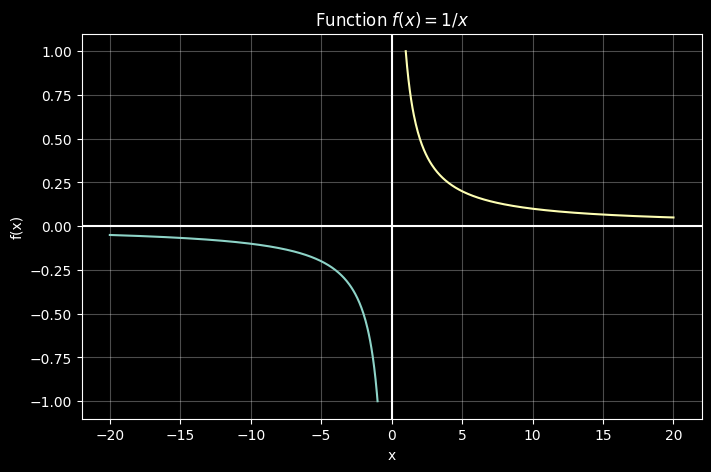

In [14]:
xs_pos = np.linspace(1, 20, 400)
xs_neg = np.linspace(-20, -1, 400)

plt.figure(figsize=(8,5))
plt.plot(xs_neg, 1/xs_neg)
plt.plot(xs_pos, 1/xs_pos)
plt.axhline(0)
plt.axvline(0)
plt.title(r"Function $f(x)=1/x$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.show()


## 15. A pendulum-style example

If $\varphi(t)$ describes the angle of a pendulum from the vertical, then physically we expect damping to make the oscillation die out.

In mathematical language, a simple damped model can behave like:

$$
\varphi(t)=e^{-0.2t}\cos(3t),
$$

and then

$$
\lim_{t\to +\infty} \varphi(t)=0.
$$


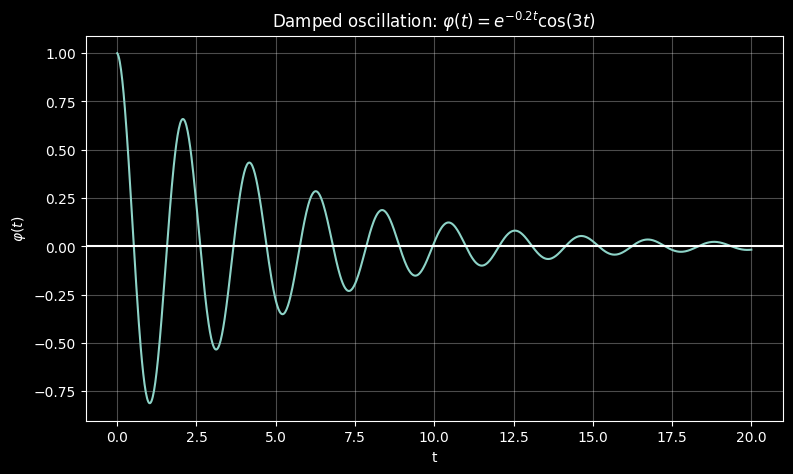

In [18]:
t = np.linspace(0, 20, 1000)
phi = np.exp(-0.2*t) * np.cos(3*t)

plt.figure(figsize=(9,5))
plt.plot(t, phi)
plt.axhline(0)
plt.title(r"Damped oscillation: $\varphi(t)=e^{-0.2t}\cos(3t)$")
plt.xlabel("t")
plt.ylabel(r"$\varphi(t)$")
plt.grid(True, alpha=0.3)
plt.show()


## 16. Important remark

A function may approach a value without ever reaching it.

Limits are about **approaching**, not necessarily **attaining**.

Also, a function may even be undefined at the point being approached, and the limit can still exist, as in the example

$$
\frac{x^2+x-2}{x-1}.
$$


## 17. Small exercises

1. Compute:
$$
\lim_{x\to 2}(x^2+3x-1)
$$

2. Compute:
$$
\lim_{x\to 3}\frac{x^2-9}{x-3}
$$

3. Does
$$
\lim_{x\to 0} \operatorname{sgn}(x)
$$
exist?

4. Compute:
$$
\lim_{x\to +\infty} \frac{1}{x^2}.
$$


In [17]:
# Sample answers with Python / symbolic support
x = sp.symbols('x')

print("1.", sp.limit(x**2 + 3*x - 1, x, 2))
print("2.", sp.limit((x**2 - 9)/(x - 3), x, 3))
print("3. The two-sided limit of sgn(x) at 0 does not exist")
print("4.", sp.limit(1/x**2, x, sp.oo))


1. 9
2. 6
3. The two-sided limit of sgn(x) at 0 does not exist
4. 0


## 18. Summary

You learned:

- a function limit describes what value the function approaches
- if the function is continuous at $a$, then
  $$
  \lim_{x\to a} f(x)=f(a)
  $$
- a limit may exist even if the function is undefined at the point
- the formal definition uses the $\varepsilon$-$\delta$ condition
- one-sided limits matter
- limits at infinity describe end behavior

Limits are one of the core tools of calculus and analysis.
